In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import numpy as np
from scipy.fftpack import dct
import numpy as np
import tensorflow.keras as K
import tensorflow.keras.backend as Kback
!pip install tensorflow-wavelets
import tensorflow_wavelets.Layers.DWT as DWT

In [5]:
!pip install -q kaggle


In [6]:
from google.colab import files
files.upload()  # <-- sélectionne ici ton fichier kaggle.json


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"hanchman","key":"09e9501dce6bf11e6cc6ea7108833c8d"}'}

In [7]:
# @title Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
import kagglehub

!kaggle datasets download -d nischaydnk/isic-2019-jpg-256x256-resized
!unzip -q isic-2019-jpg-256x256-resized.zip -d ISIC2019_256

Dataset URL: https://www.kaggle.com/datasets/nischaydnk/isic-2019-jpg-256x256-resized
License(s): CC0-1.0
 93% 414M/445M [00:06<00:00, 56.7MB/s]
100% 445M/445M [00:07<00:00, 65.8MB/s]


In [9]:
!kaggle datasets download -d nischaydnk/isic-2019-jpg-256x256-resized
!unzip -q isic-2019-jpg-256x256-resized.zip -d ISIC2019

Dataset URL: https://www.kaggle.com/datasets/nischaydnk/isic-2019-jpg-256x256-resized
License(s): CC0-1.0
isic-2019-jpg-256x256-resized.zip: Skipping, found more recently modified local copy (use --force to force download)


In [14]:
!rm -rf HAM10000


In [15]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d HAM10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [04:00<00:00, 13.6MB/s]
100% 5.20G/5.20G [04:00<00:00, 23.2MB/s]


In [16]:
import pandas as pd
import os
# Prepare ISIC2019 metadata properly
isic2019_dir = "/content/ISIC2019_256/train-image/image"
isic_df = pd.read_csv("/content/ISIC2019_256/train-metadata.csv")

# Rename for consistency
isic_df = isic_df.rename(columns={'isic_id': 'image_id', 'target': 'dx'})

# Simulate 7-class labels — this matches HAM10000 class names
# You can adjust or filter if needed
dx_label_map = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'mel',
    5: 'nv',
    6: 'vasc'
}
isic_df['dx'] = isic_df['dx'].map(dx_label_map)

# Build full image path
isic_df['path'] = isic_df['image_id'].apply(lambda x: os.path.join(isic2019_dir, x + ".jpg"))



In [17]:
isic_df['path'].apply(os.path.exists).value_counts()

,count
path,
True,25331


In [18]:
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split


# Load HAM10000 metadata
ham_dir = "/content/HAM10000"
ham_df = pd.read_csv(os.path.join(ham_dir, "HAM10000_metadata.csv"))
ham_df = ham_df.rename(columns={'dx': 'dx', 'image_id': 'image_id'})

# Build HAM image paths (part 1 + part 2)
image_dirs = ["HAM10000_images_part_1", "HAM10000_images_part_2"]
all_image_paths = []
for d in image_dirs:
    all_image_paths.extend([os.path.join(ham_dir, d, f) for f in os.listdir(os.path.join(ham_dir, d))])
ham_image_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}
ham_df['path'] = ham_df['image_id'].map(ham_image_dict)

# Keep only valid labels
valid_classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
ham_df = ham_df[ham_df['dx'].isin(valid_classes)]
isic_df = isic_df[isic_df['dx'].isin(valid_classes)]

# Combine both datasets
combined_df = pd.concat([ham_df[['image_id', 'dx', 'path']], isic_df[['image_id', 'dx', 'path']]], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check path validity
missing_path_count = combined_df['path'].isna().sum()
invalid_path_count = (~combined_df['path'].apply(os.path.exists)).sum()
print(f"Total Combined: {len(combined_df)}")
print(f"Missing paths: {missing_path_count}")
print(f"Nonexistent paths: {invalid_path_count}")

# Drop invalid paths
combined_df = combined_df[combined_df['path'].apply(os.path.exists)]

# Split into Train / Val / Test
train_df, val_df = train_test_split(combined_df, test_size=0.2, stratify=combined_df['dx'], random_state=42)
val_df, test_df = train_test_split(val_df, test_size=0.5, stratify=val_df['dx'], random_state=42)

# Copy to Skin_Disease/
splits = {'Train': train_df, 'Val': val_df, 'Test': test_df}
output_dir = "/content/Skin_Disease"

for split_name, df_split in splits.items():
    for label in valid_classes:
        os.makedirs(os.path.join(output_dir, split_name, label), exist_ok=True)
    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=f"Copying {split_name}"):
        dst = os.path.join(output_dir, split_name, row['dx'], os.path.basename(row['path']))
        shutil.copyfile(row['path'], dst)

Total Combined: 35346
Missing paths: 0
Nonexistent paths: 0


Copying Test: 100%|██████████| 3535/3535 [00:03<00:00, 944.59it/s] 


In [19]:
print("Total Combined:", len(combined_df))
print("Missing paths:", combined_df['path'].isna().sum())
print("Nonexistent paths:", (~combined_df['path'].apply(os.path.exists)).sum())

Total Combined: 35346
Missing paths: 0
Nonexistent paths: 0


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen.flow_from_directory(
    '/content/Skin_Disease/Train', target_size=(256, 256), batch_size=64,
    class_mode='categorical', shuffle=True
)

validation_dataset = val_datagen.flow_from_directory(
    '/content/Skin_Disease/Val', target_size=(256, 256), batch_size=64,
    class_mode='categorical', shuffle=True
)

test_dataset = test_datagen.flow_from_directory(
    '/content/Skin_Disease/Test', target_size=(256, 256), batch_size=64,
    class_mode='categorical', shuffle=False
)

Found 28064 images belonging to 7 classes.
Found 3534 images belonging to 7 classes.
Found 3529 images belonging to 7 classes.


In [21]:
print(train_dataset.class_indices)
print(validation_dataset.class_indices)
print(test_dataset.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [22]:
def f1_score(y_true, y_pred):
    true_positives = Kback.sum(Kback.round(Kback.clip(y_true * y_pred, 0, 1)))
    possible_positives = Kback.sum(Kback.round(Kback.clip(y_true, 0, 1)))
    predicted_positives = Kback.sum(Kback.round(Kback.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + Kback.epsilon())
    recall = true_positives / (possible_positives + Kback.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+Kback.epsilon())
    return f1_val

METRICS = [
      "accuracy",
      K.metrics.Precision(name='precision'),
      K.metrics.Recall(name='recall'),
      K.metrics.AUC(name='auc'),
      f1_score
]

In [23]:
def fft_2d(feature_map):
    feature_map = tf.cast(feature_map, tf.complex64)
    X1 = tf.signal.fft2d(feature_map)
    X1 = tf.abs(X1)
    return X1

In [24]:
import tensorflow as tf
from tensorflow.keras import layers

class SaFALayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SaFALayer, self).__init__(**kwargs)
        self.sepconv1 = layers.SeparableConv2D(256, 5, padding="same")
        self.sepconv2 = layers.SeparableConv2D(64, 3, padding="same")
        self.sepconv3 = layers.SeparableConv2D(1, 1, padding="same")
        self.conv_fuse1 = layers.SeparableConv2D(256, 1, strides=(2, 2), padding="same")
        self.conv_fuse2 = layers.SeparableConv2D(64, 3, padding="same")
        self.conv_fuse3 = layers.SeparableConv2D(1, 1, padding="same", activation='sigmoid')
        self.pool = layers.MaxPooling2D(pool_size=(2, 2), padding="same")

    def build(self, input_shape):
        super(SaFALayer, self).build(input_shape)

    def similarity(self, x):
        # x shape: (B, H, W, C)
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x_flat = tf.reshape(x, [B, H * W, C])  # (B, N, C)
        x_t = tf.transpose(x_flat, perm=[0, 2, 1])  # (B, C, N)
        sim = tf.matmul(x_flat, x_t)  # (B, N, N)
        sim = tf.expand_dims(sim, axis=-1)  # (B, N, N, 1)
        return sim, H, W, C

    def call(self, inputs):
        x = self.sepconv1(inputs)
        x = self.sepconv2(x)
        x = self.sepconv3(x)

        sim, H, W, C = self.similarity(x)

        B = tf.shape(x)[0]
        N = H * W

        # reshape input to (B, N, C)
        input_flat = tf.reshape(inputs, [B, N, tf.shape(inputs)[-1]])  # shape: (B, N, C)
        input_flat = tf.expand_dims(input_flat, axis=1)  # (B, 1, N, C)

        # Multiply similarity with reshaped inputs
        attn = sim * input_flat  # (B, N, N, C)
        attn = tf.reduce_mean(attn, axis=2)  # (B, N, C)

        # reshape back to (B, H, W, C)
        attn_reshaped = tf.reshape(attn, [B, H, W, tf.shape(attn)[-1]])

        x = self.conv_fuse1(attn_reshaped)
        x = self.conv_fuse2(x)
        x = self.conv_fuse3(x)

        pooled = self.pool(inputs)

        return pooled * x

In [25]:
class Gradients(K.layers.Layer):
    def call(self, inputs):
        alpha = inputs
        gradients_alpha = tf.gradients(alpha, [alpha])[0]
        a = tf.reduce_mean(gradients_alpha, axis=[-1,-2,-3], keepdims=True)
        return a

In [26]:
class SoftAttention(K.layers.Layer):
    def __init__(self,ch,m,concat_with_x=False,aggregate=False,**kwargs):
        self.channels=int(ch)
        self.multiheads = m
        self.aggregate_channels = aggregate
        self.concat_input_with_scaled = concat_with_x


        super(SoftAttention,self).__init__(**kwargs)

    def build(self,input_shape):

        self.i_shape = input_shape

        kernel_shape_conv3d = (self.channels, 3, 3) + (1, self.multiheads) # DHWC

        self.out_attention_maps_shape = input_shape[0:1]+(self.multiheads,)+input_shape[1:-1]

        if self.aggregate_channels==False:

            self.out_features_shape = input_shape[:-1]+(input_shape[-1]+(input_shape[-1]*self.multiheads),)
        else:
            if self.concat_input_with_scaled:
                self.out_features_shape = input_shape[:-1]+(input_shape[-1]*2,)
            else:
                self.out_features_shape = input_shape


        self.kernel_conv3d = self.add_weight(shape=kernel_shape_conv3d,
                                        initializer='he_uniform',
                                        name='kernel_conv3d')
        self.bias_conv3d = self.add_weight(shape=(self.multiheads,),
                                      initializer='zeros',
                                      name='bias_conv3d')

        super(SoftAttention, self).build(input_shape)

    def call(self, x):

        exp_x = Kback.expand_dims(x,axis=-1)

        c3d = Kback.conv3d(exp_x,
                     kernel=self.kernel_conv3d,
                     strides=(1,1,self.i_shape[-1]), padding='same', data_format='channels_last')
        conv3d = Kback.bias_add(c3d,
                        self.bias_conv3d)
        conv3d = K.layers.Activation('relu')(conv3d)

        conv3d = Kback.permute_dimensions(conv3d,pattern=(0,4,1,2,3))


        conv3d = Kback.squeeze(conv3d, axis=-1)
        conv3d = Kback.reshape(conv3d,shape=(-1, self.multiheads ,self.i_shape[1]*self.i_shape[2]))

        softmax_alpha = Kback.softmax(conv3d, axis=-1)
        softmax_alpha = K.layers.Reshape(target_shape=(self.multiheads, self.i_shape[1],self.i_shape[2]))(softmax_alpha)


        if self.aggregate_channels==False:
            exp_softmax_alpha = Kback.expand_dims(softmax_alpha, axis=-1)
            exp_softmax_alpha = Kback.permute_dimensions(exp_softmax_alpha,pattern=(0,2,3,1,4))

            x_exp = Kback.expand_dims(x,axis=-2)

            u = K.layers.Multiply()([exp_softmax_alpha, x_exp])

            u = K.layers.Reshape(target_shape=(self.i_shape[1],self.i_shape[2],u.shape[-1]*u.shape[-2]))(u)

        else:
            exp_softmax_alpha = Kback.permute_dimensions(softmax_alpha,pattern=(0,2,3,1))

            exp_softmax_alpha = Kback.sum(exp_softmax_alpha,axis=-1)

            exp_softmax_alpha = Kback.expand_dims(exp_softmax_alpha, axis=-1)

            u = K.layers.Multiply()([exp_softmax_alpha, x])

        if self.concat_input_with_scaled:
            o = K.layers.Concatenate(axis=-1)([u,x])
        else:
            o = u

        return [o, softmax_alpha]

    def compute_output_shape(self, input_shape):
        return [self.out_features_shape, self.out_attention_maps_shape]


    def get_config(self):
        return super(SoftAttention,self).get_config()

In [27]:
input_layer = K.Input(shape=(256,256,3))
deep_learner = K.applications.DenseNet121(include_top = False, weights = "imagenet", input_tensor = input_layer)
for layer in deep_learner.layers:
    layer.trainable = True
# for i, layer in enumerate(deep_learner.layers):
#     print(i, layer.name, "-", layer.trainable)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [28]:
data_augmentation = K.Sequential([
    K.layers.RandomFlip("horizontal_and_vertical"),
    K.layers.RandomRotation(0.2),
    K.layers.RandomZoom(0.2),
    K.layers.RandomBrightness(0.1)
])

In [29]:
import tensorflow.keras as K
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Input
input_img = K.layers.Input(shape=(256, 256, 3))
augmented = data_augmentation(input_img)
feat_img = deep_learner(augmented)


# Feature extractor
feat_img = deep_learner(input_img)

# Wavelet transform
wav = DWT.DWT(name="haar", concat=0)(feat_img)
wav = K.layers.SeparableConv2D(1024, 1, padding="same")(wav)

# Soft attention
attention_layer, map2 = SoftAttention(
    aggregate=True,
    m=16,
    concat_with_x=False,
    ch=int(feat_img.shape[-1]),
    name='soft_attention'
)(feat_img)
attention_layer = K.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(attention_layer)

# Gradients
grad_attn = Gradients()(attention_layer)
grad_wav = Gradients()(wav)

# Avoid division by zero
eps = 1e-7
grad_attn_weight = 1 - (grad_attn / (grad_attn + grad_wav + eps))
grad_wav_weight = 1 - (grad_wav / (grad_attn + grad_wav + eps))

# Fusion of attention and wavelet
attention_layer = grad_attn_weight * attention_layer + grad_wav_weight * wav

# Spatial and frequency attention fusion
safa_out = SaFALayer()(feat_img)
conv = K.layers.Concatenate()([safa_out, attention_layer])
conv = K.layers.Activation('relu')(conv)

# Classification head
flat = K.layers.GlobalAveragePooling2D()(conv)
output = K.layers.Dense(7, activation='softmax')(flat)

# Define and compile model
model = Model(inputs=input_img, outputs=output)
optimizer = K.optimizers.Adam(learning_rate=1e-4)


model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=METRICS  # Example: ['accuracy'] or a custom F1/Recall/Precision setup
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 8, 8,      │  7,037,504 │ input_layer_1[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soft_attention      │ [(None, 8, 8,     │    147,472 │ densenet121[1][0] │
│ (SoftAttention)     │ 1024), (None, 16, │            │                   │
│                     │ 8, 8)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ haar (DWT)          │ (None, 4, 4,      │          0 │ densenet121[1][0] │
│                     │ 4096)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 4, 4,      │          0 │ soft_attention[0… │
│ (MaxPooling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 4, 4,      │  4,199,424 │ haar[0][0]        │
│ (SeparableConv2D)   │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradients           │ (None, 1, 1, 1)   │          0 │ max_pooling2d[0]… │
│ (Gradients)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradients_1         │ (None, 1, 1, 1)   │          0 │ separable_conv2d… │
│ (Gradients)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 1)   │          0 │ gradients[0][0],  │
│                     │                   │            │ gradients_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 1, 1)   │          0 │ gradients[0][0],  │
│                     │                   │            │ gradients_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1, 1)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 1, 1)   │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 1, 1, 1)   │          0 │ gradients[0][0],  │
│ (TrueDivide)        │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 1, 1, 1)   │          0 │ gradients_1[0][0… │
│ (TrueDivide)        │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 1, 1, 1)   │          0 │ true_divide[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 1, 1, 1)   │          0 │ true_divide_1[0]… │
│ (Subtract)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 4, 4,      │          0 │ subtract[0][0],   │
│                     │ 1024)             │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,987,929 (45.73 MB)

 Trainable params: 11,904,281 (45.41 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [30]:
model_checkpoint_callback = K.callbacks.ModelCheckpoint(
    filepath='densenet121_SA.weights.h5',
    monitor='val_f1_score',  # or 'val_accuracy' if not using custom F1
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=validation_dataset,
    verbose=1,
    callbacks=[model_checkpoint_callback],
    shuffle=True
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.8029 - auc: 0.9702 - f1_score: 0.7700 - loss: 0.5630 - precision: 0.8531 - recall: 0.7354
Epoch 1: val_f1_score improved from -inf to 0.83936, saving model to densenet121_SA.weights.h5
439/439 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - accuracy: 0.8030 - auc: 0.9703 - f1_score: 0.7701 - loss: 0.5627 - precision: 0.8531 - recall: 0.7356 - val_accuracy: 0.8410 - val_auc: 0.9849 - val_f1_score: 0.8394 - val_loss: 0.4145 - val_precision: 0.8645 - val_recall: 0.8178
Epoch 2/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.8934 - auc: 0.9929 - f1_score: 0.8931 - loss: 0.2753 - precision: 0.9028 - recall: 0.8839
Epoch 2: val_f1_score improved from 0.83936 to 0.87072, saving model to densenet121_SA.weights.h5
439/439 ━━━━━━━━━━━━━━━━━━━━ 354s 784ms/step - accuracy: 0.8934 - auc: 0.9929 - f1_score: 0.8931 - loss: 0.2753 - precision: 0.9028 - recall: 0.8839 - val_accuracy: 0.8738 - val_auc: 0.9891 - val_f1_score: 0.8707 - val_loss: 0.3

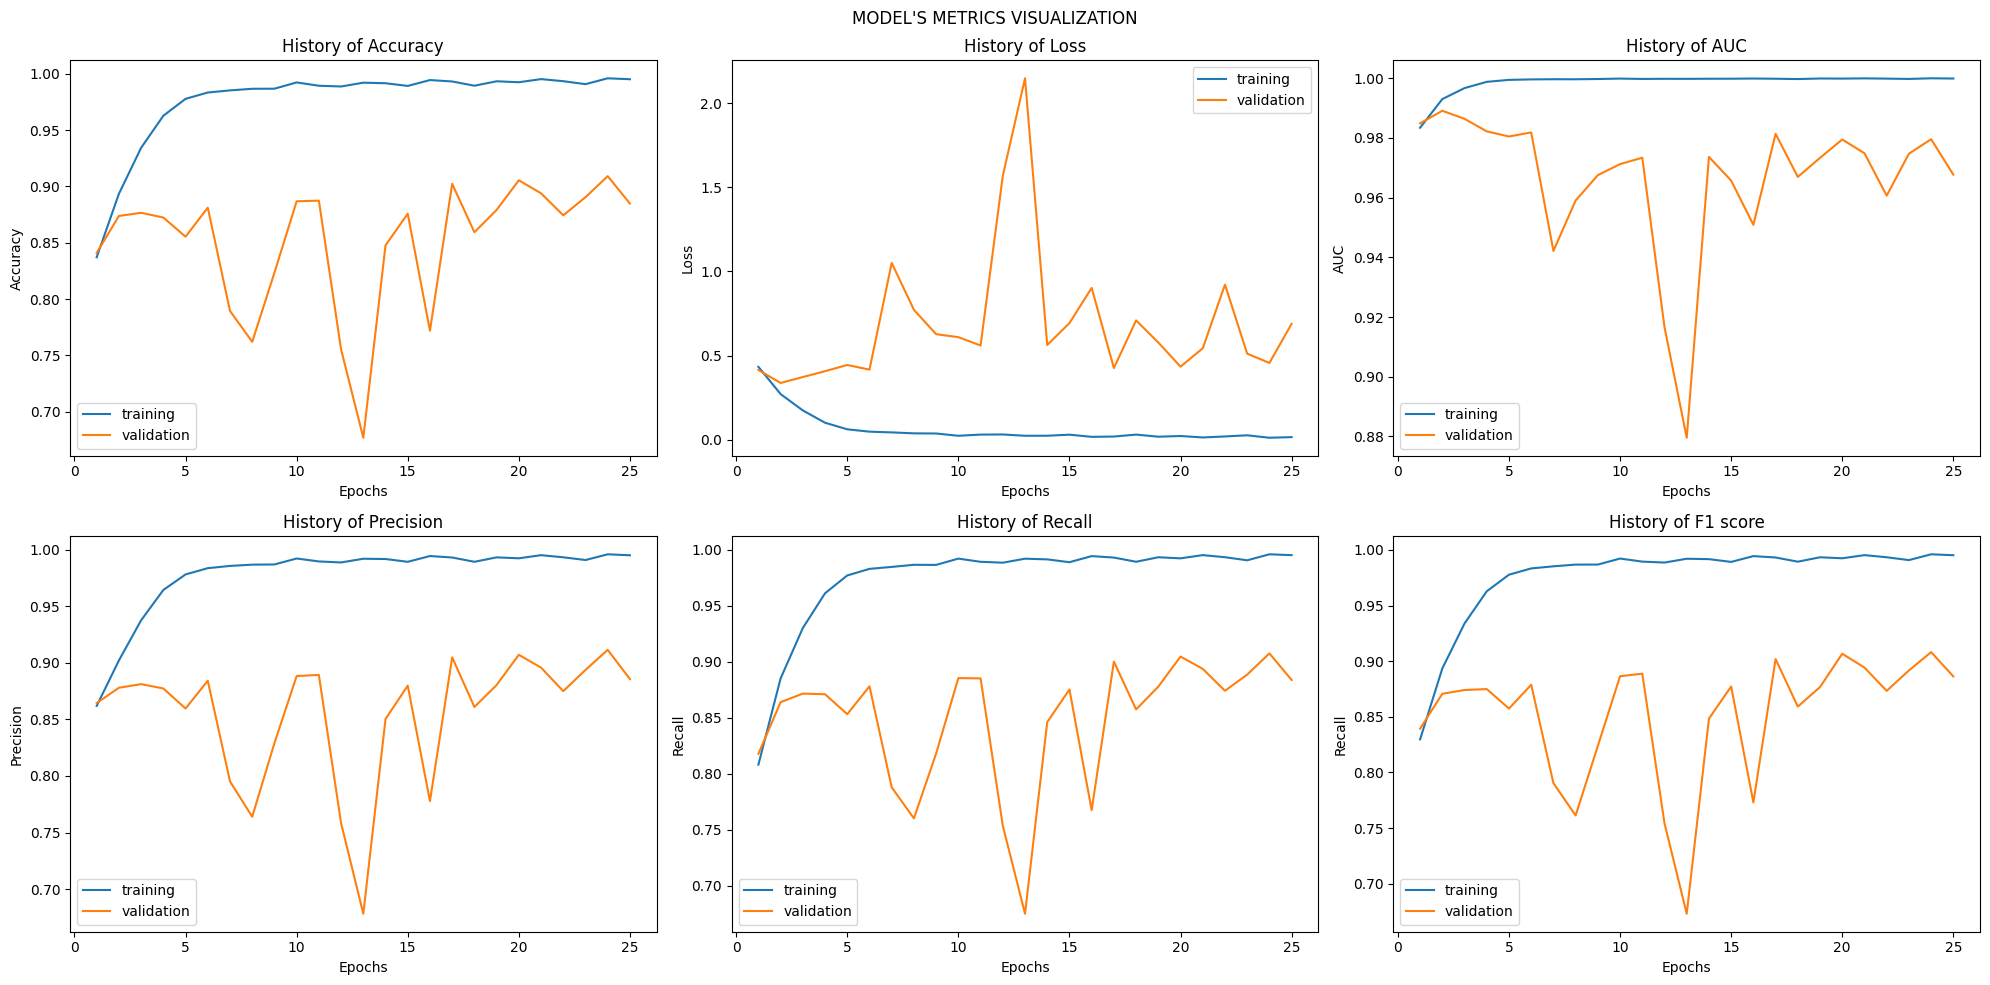

In [31]:
import matplotlib.pyplot as plt

def Train_Val_Plot(acc, val_acc, loss, val_loss, auc, val_auc, precision, val_precision, recall, val_recall, f1_score, val_f1_score):
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle("MODEL'S METRICS VISUALIZATION")

    axes[0, 0].plot(range(1, len(acc) + 1), acc)
    axes[0, 0].plot(range(1, len(val_acc) + 1), val_acc)
    axes[0, 0].set_title('History of Accuracy')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend(['training', 'validation'])

    axes[0, 1].plot(range(1, len(loss) + 1), loss)
    axes[0, 1].plot(range(1, len(val_loss) + 1), val_loss)
    axes[0, 1].set_title('History of Loss')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend(['training', 'validation'])

    axes[0, 2].plot(range(1, len(auc) + 1), auc)
    axes[0, 2].plot(range(1, len(val_auc) + 1), val_auc)
    axes[0, 2].set_title('History of AUC')
    axes[0, 2].set_xlabel('Epochs')
    axes[0, 2].set_ylabel('AUC')
    axes[0, 2].legend(['training', 'validation'])

    axes[1, 0].plot(range(1, len(precision) + 1), precision)
    axes[1, 0].plot(range(1, len(val_precision) + 1), val_precision)
    axes[1, 0].set_title('History of Precision')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend(['training', 'validation'])

    axes[1, 1].plot(range(1, len(recall) + 1), recall)
    axes[1, 1].plot(range(1, len(val_recall) + 1), val_recall)
    axes[1, 1].set_title('History of Recall')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend(['training', 'validation'])

    axes[1, 2].plot(range(1, len(f1_score) + 1), f1_score)
    axes[1, 2].plot(range(1, len(val_f1_score) + 1), val_f1_score)
    axes[1, 2].set_title('History of F1 score')
    axes[1, 2].set_xlabel('Epochs')
    axes[1, 2].set_ylabel('Recall')  # Corrected from 'Recall' to 'F1 score'
    axes[1, 2].legend(['training', 'validation'])

    plt.tight_layout()
    plt.show()

# Call the function with your history data
Train_Val_Plot(history.history['accuracy'], history.history['val_accuracy'],
               history.history['loss'], history.history['val_loss'],
               history.history['auc'], history.history['val_auc'],
               history.history['precision'], history.history['val_precision'],
               history.history['recall'], history.history['val_recall'],
               history.history['f1_score'], history.history['val_f1_score'])

In [32]:
# Correct path to weights file
model.load_weights("densenet121_SA.weights.h5")

# Evaluate the model
loss, accuracy, precision, recall, auc, f1_score = model.evaluate(test_dataset)
print("Accuracy:", accuracy)
print("Loss:", loss)
print("Precision:", precision)
print("Recall:", recall)
print("AUC:", auc)
print("F1-score:", f1_score)

56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 577ms/step - accuracy: 0.9347 - auc: 0.9864 - f1_score: 0.9344 - loss: 0.3013 - precision: 0.9351 - recall: 0.9340
Accuracy: 0.9011051058769226
Loss: 0.5100992918014526
Precision: 0.902556836605072
Recall: 0.900255024433136
AUC: 0.976498544216156
F1-score: 0.8992123007774353


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(64, 256, 256, 3))
  warnings.warn(msg)


56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 523ms/step
Confusion Matrix


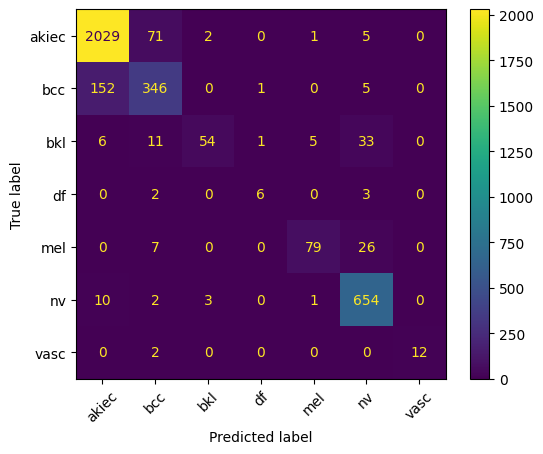

Classification Report
              precision    recall  f1-score   support

       akiec       0.92      0.96      0.94      2108
         bcc       0.78      0.69      0.73       504
         bkl       0.92      0.49      0.64       110
          df       0.75      0.55      0.63        11
         mel       0.92      0.71      0.80       112
          nv       0.90      0.98      0.94       670
        vasc       1.00      0.86      0.92        14

    accuracy                           0.90      3529
   macro avg       0.88      0.75      0.80      3529
weighted avg       0.90      0.90      0.90      3529



In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels
y_true = test_dataset.classes

# Get predictions
Y_pred = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix
print('Confusion Matrix')
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=test_dataset.class_indices.keys()
)
disp.plot(xticks_rotation=45)
plt.grid(False)
plt.show()

# Classification Report
print('Classification Report')
target_names = list(test_dataset.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))